In [1]:
## Requested libraries

# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from datetime import datetime

In [ ]:
Azores 

    minimum_longitude=-67.5,  # Western boundary
    maximum_longitude=-60,    # Eastern boundary
    minimum_latitude=10,      # Southern boundary
    maximum_latitude=19.5,    # Northern boundary

Canary

    minimum_longitude=-18,   # Western boundary
    maximum_longitude=-12,   # Eastern boundary
    minimum_latitude=27,     # Southern boundary
    maximum_latitude=31,     # Northern boundary

Cape Verde

    minimum_longitude=-25,   # Western boundary
    maximum_longitude=-22,   # Eastern boundary
    minimum_latitude=14,     # Southern boundary
    maximum_latitude=18,     # Northern boundary


In [23]:
#### DATA DOWNLOAD


import copernicusmarine

# Data download
# Long temporal coverage and small spatial coverage
# just for azores now

# Subset the dataset
copernicusmarine.subset(
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
    variables=["analysed_sst"],
    minimum_longitude=-25,   # Western boundary
    maximum_longitude=-22,   # Eastern boundary
    minimum_latitude=14,     # Southern boundary
    maximum_latitude=18,     # Northern boundary
    start_datetime="1985-01-01",
    end_datetime="2023-12-31",
    output_directory="/silod7/ramos/Maca/data"
)



INFO - 2025-12-18T11:18:14Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

INFO - 2025-12-18T11:18:21Z - Selected dataset version: "202003"
INFO - 2025-12-18T11:18:21Z - Selected dataset part: "default"
INFO - 2025-12-18T11:18:22Z - Starting download. Please wait...
100%|██████████| 67/67 [00:04<00:00, 16.52it/s]
INFO - 2025-12-18T11:18:26Z - Successfully downloaded to /silod7/ramos/Maca/data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_24.98W-22.02W_14.02N-17.98N_1985-01-01-2023-12-31.nc


ResponseSubset(file_path=PosixPath('/silod7/ramos/Maca/data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_24.98W-22.02W_14.02N-17.98N_1985-01-01-2023-12-31.nc'), output_directory=PosixPath('/silod7/ramos/Maca/data'), filename='METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_24.98W-22.02W_14.02N-17.98N_1985-01-01-2023-12-31.nc', file_size=130.4923893129771, data_transfer_size=1044.714503816794, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=-24.975000381469727, maximum=-22.024999618530273, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=14.024999618530273, maximum=17.975000381469727, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='1985-01-01T00:00:00+00:00', maximum='2023-12-31T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [24]:
# Open Input Data File

DataFileName = '/silod7/ramos/Maca/data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_24.98W-22.02W_14.02N-17.98N_1985-01-01-2023-12-31.nc'

# Open the datafile
DS = xr.open_dataset(DataFileName)

# Show info of dataset
DS

<xarray.Dataset> Size: 547MB
Dimensions:       (time: 14244, latitude: 80, longitude: 60)
Coordinates:
  * time          (time) datetime64[ns] 114kB 1985-01-01 ... 2023-12-31
  * latitude      (latitude) float32 320B 14.02 14.07 14.12 ... 17.92 17.98
  * longitude     (longitude) float32 240B -24.98 -24.92 ... -22.08 -22.02
Data variables:
    analysed_sst  (time, latitude, longitude) float64 547MB ...
Attributes:
    references:                Donlon, C.J., Martin, M., Stark, J.D., Roberts...
    comment:                   WARNING Some applications are unable to proper...
    history:                   Created from sst.nc; obs_anal.nc; seaice.nc
    source:                    AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, GO...
    title:                     Global SST & Sea Ice Analysis, L4 OSTIA, 0.05 ...
    institution:               UKMO
    Conventions:               CF-1.4, ACDD-1.3
    copernicusmarine_version:  2.2.5

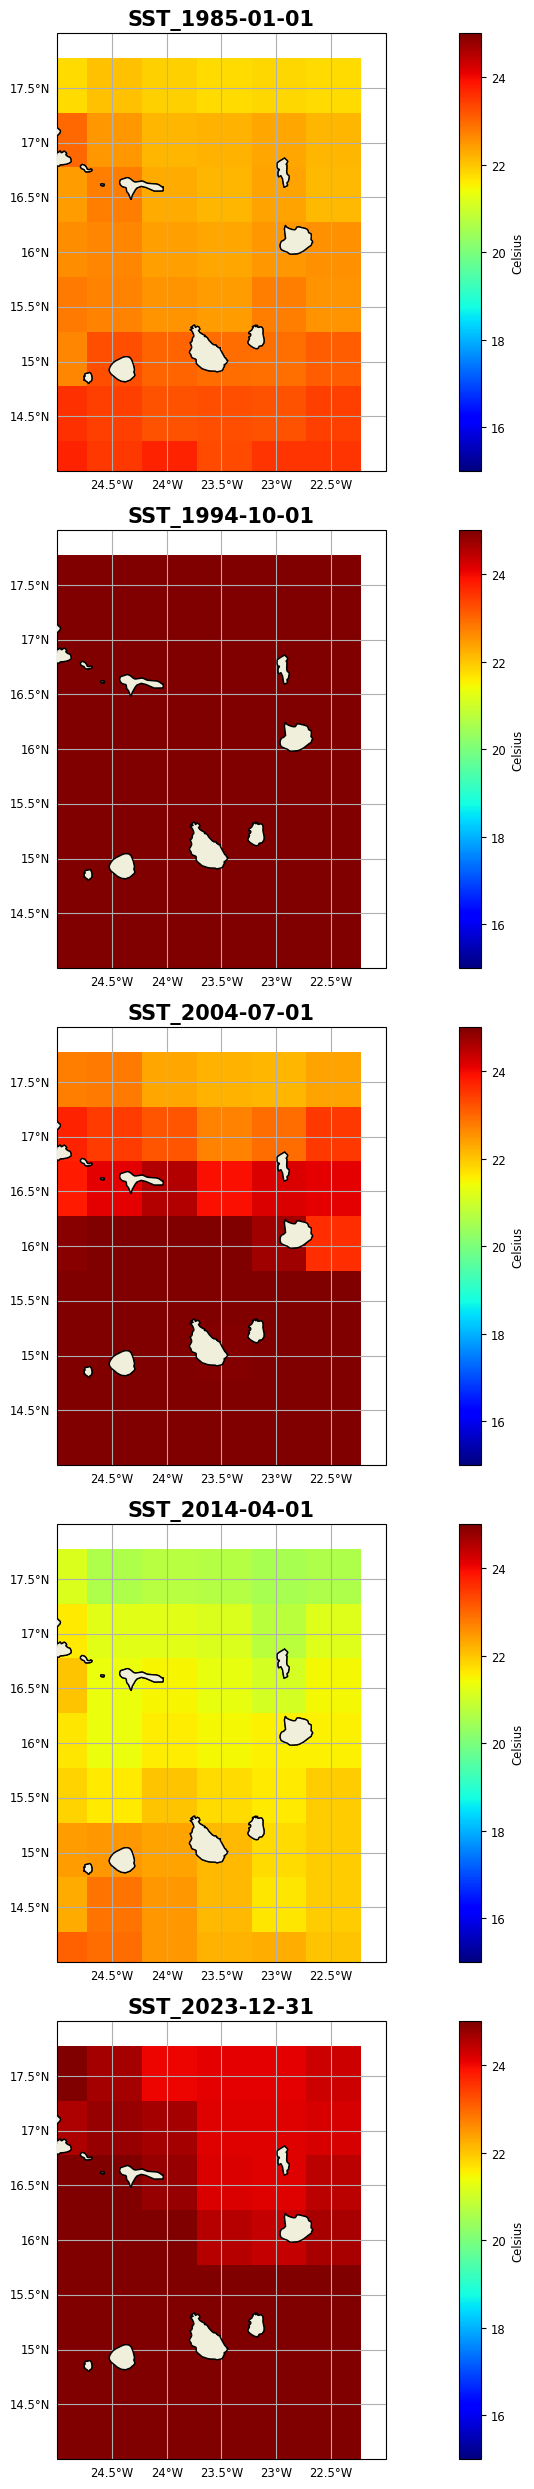

In [25]:
### QUICK VIEW

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define the PlotMap function
def PlotMap(Fig, Ax, Data, Title, ColorbarRange):
    '''
    Plot a map with coastlines, gridlines, and data
    '''
    Ax.coastlines()
    Gl = Ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    Gl.right_labels = False
    Gl.top_labels = False
    Gl.xlabel_style = {'size': 'small'}
    Gl.ylabel_style = {'size': 'small'}
    Ax.add_feature(cfeature.LAND, zorder=10, edgecolor='k')
    Ax.add_feature(cfeature.BORDERS, linestyle=':')
    #Ax.set_extent([-32, -24, 36, 40], crs=ccrs.PlateCarree()) #azores
    #Ax.set_extent([-19, -12, 27, 31], crs=ccrs.PlateCarree())   # Canary Islands extent 
    Ax.set_extent([-25, -22, 14, 18], crs=ccrs.PlateCarree())  # Cape Verde
    
    # Plot data
    Map = Ax.pcolormesh(
        Data['longitude'], Data['latitude'], Data,
        vmin=ColorbarRange[0], vmax=ColorbarRange[1],
        cmap='jet', shading='auto'
    )

    Ax.set_title(Title, fontsize=15, fontweight="bold")
    CBar = plt.colorbar(Map, ax=Ax)
    CBar.ax.tick_params(labelsize='small')
    CBar.set_label(label='Celsius', fontsize='small')
    return

# Parameters for downsampling
SkipXY = 10
NFigures = 5
time_indices = np.linspace(0, DS.time.size-1, NFigures, dtype=int)

# Create figure
Fig = plt.figure(figsize=(15, 5*NFigures))

# Loop over selected timesteps
for n, idx in enumerate(time_indices):
    Date = DS['time'][idx]
    DateFormat = Date.dt.strftime("%Y-%m-%d").values
    PlotTitle = 'SST_{}'.format(DateFormat)
    
    # Select and downsample spatially
    D2P = DS['analysed_sst'].isel(time=idx).sel(
        latitude=slice(None, None, SkipXY),
        longitude=slice(None, None, SkipXY)
    ).squeeze()
    
    Ax = plt.subplot(NFigures, 1, n+1, projection=ccrs.PlateCarree())
    PlotMap(Fig, Ax, D2P-273.15, PlotTitle, [15, 25])  # convert Kelvin -> Celsius

plt.tight_layout()
plt.show()


##### MHW CALCULATION

In [1]:
import numpy as np
import xarray as xr
from datetime import datetime
import marineHeatWaves as mhw
from multiprocessing import Pool
import tqdm

ModuleNotFoundError: No module named 'marineHeatWaves'

In [6]:
DataFileName = '/silod7/ramos/Maca/data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_31.98W-24.02W_36.03N-39.97N_1985-01-01-2023-12-31.nc'

# Open the datafile
DS = xr.open_dataset(DataFileName)

In [26]:
# --- Convert time to ordinal ---
def ToDatetime(date):
    """Convert numpy.datetime64 to python datetime"""
    timestamp = ((date - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's'))
    return datetime.utcfromtimestamp(timestamp)

time_values = DS['time'].values
DatesDT = np.array([ToDatetime(d) for d in time_values])
DatesORD = np.array([d.toordinal() for d in DatesDT])

In [27]:
# --- Convert SST from Kelvin to Celsius if needed ---
sst_da = DS['analysed_sst']
if float(sst_da.mean()) > 100:
    print("Converting Kelvin -> Celsius")
    sst_da = sst_da - 273.15

# Fill small NaN gaps to avoid empty detection
sst_da = sst_da.interpolate_na(dim='time', method='linear', fill_value="extrapolate")

Converting Kelvin -> Celsius


In [28]:
# --- Convert time to ordinal days for mhw.detect ---
def ToDatetime(date64):
    timestamp = ((date64 - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's'))
    return datetime.utcfromtimestamp(timestamp)

DatesORD = np.array([d.toordinal() for d in map(ToDatetime, sst_da.time.values)])

# --- Prepare grid dimensions ---
ny, nx = sst_da.shape[1], sst_da.shape[2]

# --- Function to detect MHW events for a single cell ---
def detect_cell(args):
    i, j, ts = args
    ts = ts.astype(float)
    
    if np.all(np.isnan(ts)):
        return (i, j, None, None)
    
    try:
        mhws, clim = mhw.detect(DatesORD, ts)
        return (i, j, mhws, clim)
    except Exception as e:
        return (i, j, None, None)

# --- Prepare arguments list ---
args_list = [(i, j, sst_da[:, i, j].values) for i in range(ny) for j in range(nx)]

# --- Run in parallel ---
num_cores = 8  # adjust to your CPU
results = []

with Pool(processes=num_cores) as pool:
    for res in tqdm.tqdm(pool.imap_unordered(detect_cell, args_list), total=len(args_list)):
        results.append(res)

# --- Organize results ---
mhws_map = np.empty((ny, nx), dtype=object)
clim_map = np.empty((ny, nx), dtype=object)

for i, j, mhws, clim in results:
    mhws_map[i, j] = mhws
    clim_map[i, j] = clim

# Convert to xarray for convenience
mhws_da = xr.DataArray(mhws_map, coords={'latitude': sst_da.latitude, 'longitude': sst_da.longitude}, dims=['latitude','longitude'])
clim_da = xr.DataArray(clim_map, coords={'latitude': sst_da.latitude, 'longitude': sst_da.longitude}, dims=['latitude','longitude'])

print("MHW detection complete! Data ready for classification later.")


100%|██████████| 4800/4800 [03:00<00:00, 26.60it/s]


MHW detection complete! Data ready for classification later.


In [29]:
count_cells = np.sum([x is not None for x in mhws_da.values.flatten()])
total_cells = mhws_da.size
print(f"{count_cells}/{total_cells} grid cells have MHW events")

4744/4800 grid cells have MHW events


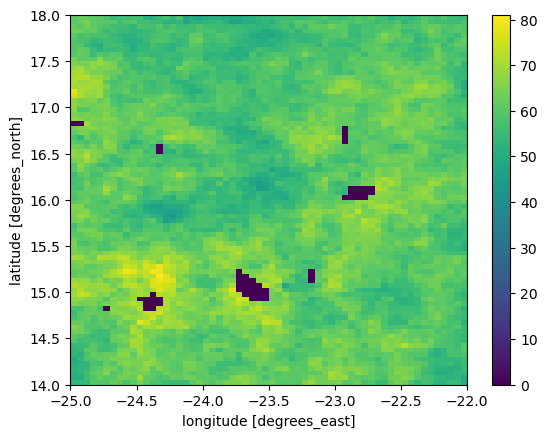

In [30]:
# mean events of all MHWs per cell.

events_per_cell = np.zeros((ny, nx))

for i in range(ny):
    for j in range(nx):
        cell = mhws_da[i, j].item()
        if cell not in [None, np.nan]:
            events_per_cell[i, j] = len(cell['time_start'])

events_da = xr.DataArray(
    events_per_cell,
    coords={'latitude': sst_da.latitude, 'longitude': sst_da.longitude},
    dims=['latitude','longitude']
)

events_da.plot()


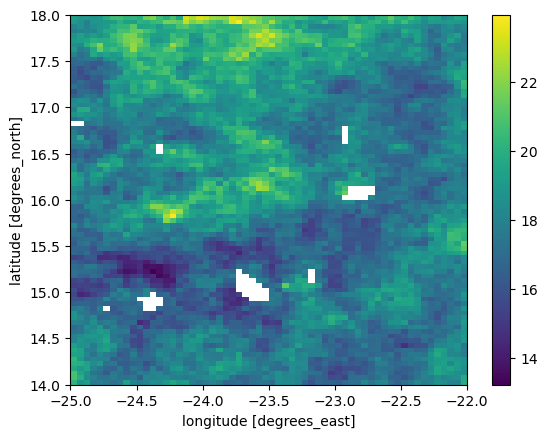

In [31]:
#mean duration of all MHWs per cell.

mean_duration = np.full((ny, nx), np.nan)

for i in range(ny):
    for j in range(nx):
        cell = mhws_da[i, j].item()
        if cell is not None:
            durations = cell["duration"]
            mean_duration[i, j] = np.mean(durations)


mean_duration_da = xr.DataArray(
    mean_duration,
    coords={'latitude': sst_da.latitude, 'longitude': sst_da.longitude},
    dims=['latitude','longitude']
)
mean_duration_da.plot()


In [32]:
#all events into a single pandas table
# 
records = []

for i in range(ny):
    for j in range(nx):
        cell = mhws_da[i, j].item()
        if cell is None:
            continue
        
        lat = float(mhws_da.latitude[i])
        lon = float(mhws_da.longitude[j])

        for n in range(len(cell['duration'])):
            records.append({
                "lat": lat,
                "lon": lon,
                "start": cell["time_start"][n],
                "end": cell["time_end"][n],
                "duration": cell["duration"][n],
                "intensity_max": cell["intensity_max"][n],
                "intensity_mean": cell["intensity_mean"][n],
            })

import pandas as pd
df_events = pd.DataFrame(records)
df_events.head()


,lat,lon,start,end,duration,intensity_max,intensity_mean
0,14.025,-24.975,728602,728607,6,0.975080,0.920358
1,14.025,-24.975,728658,728668,11,2.040363,1.689054
2,14.025,-24.975,728687,728692,6,1.428842,1.310128
3,14.025,-24.975,729176,729181,6,1.490577,1.368058
4,14.025,-24.975,729423,729459,37,2.620656,1.620023


In [33]:
df_events.to_csv("/silod7/ramos/Maca/cv_mhw_events.csv", index=False)

In [34]:
df = pd.read_csv("/silod7/ramos/Maca/cv_mhw_events.csv")
df

,lat,lon,start,end,duration,intensity_max,intensity_mean
0,14.025,-24.975,728602,728607,6,0.975080,0.920358
1,14.025,-24.975,728658,728668,11,2.040363,1.689054
2,14.025,-24.975,728687,728692,6,1.428842,1.310128
3,14.025,-24.975,729176,729181,6,1.490577,1.368058
4,14.025,-24.975,729423,729459,37,2.620656,1.620023
...,...,...,...,...,...,...,...
285751,17.975,-22.025,738607,738614,8,1.813163,1.556457
285752,17.975,-22.025,738629,738664,36,1.998572,1.545756
285753,17.975,-22.025,738672,738785,114,3.380897,2.271969
285754,17.975,-22.025,738791,738831,41,2.702756,1.850852


In [35]:
import pandas as pd
import numpy as np

# Your dataframe: df
# columns: lat, lon, start, end, duration, intensity_max, intensity_mean

def classify_hobday(intensity):
    if intensity <= 1.5:
        return "Moderate"
    elif intensity <= 2.5:
        return "Strong"
    elif intensity <= 3.5:
        return "Severe"
    else:
        return "Extreme"

df["class"] = df["intensity_max"].apply(classify_hobday)
df

,lat,lon,start,end,duration,intensity_max,intensity_mean,class
0,14.025,-24.975,728602,728607,6,0.975080,0.920358,Moderate
1,14.025,-24.975,728658,728668,11,2.040363,1.689054,Strong
2,14.025,-24.975,728687,728692,6,1.428842,1.310128,Moderate
3,14.025,-24.975,729176,729181,6,1.490577,1.368058,Moderate
4,14.025,-24.975,729423,729459,37,2.620656,1.620023,Severe
...,...,...,...,...,...,...,...,...
285751,17.975,-22.025,738607,738614,8,1.813163,1.556457,Strong
285752,17.975,-22.025,738629,738664,36,1.998572,1.545756,Strong
285753,17.975,-22.025,738672,738785,114,3.380897,2.271969,Severe
285754,17.975,-22.025,738791,738831,41,2.702756,1.850852,Severe


In [36]:
from datetime import datetime

def ordinal_to_datetime_mhw(ordinal):
    # MHW uses Matlab ordinal → subtract 366
    return datetime.fromordinal(int(ordinal) - 366)

df["date"] = df["start"].apply(ordinal_to_datetime_mhw)
df["year"] = df["date"].dt.year
df

,lat,lon,start,end,duration,intensity_max,intensity_mean,class,date,year
0,14.025,-24.975,728602,728607,6,0.975080,0.920358,Moderate,1994-11-04,1994
1,14.025,-24.975,728658,728668,11,2.040363,1.689054,Strong,1994-12-30,1994
2,14.025,-24.975,728687,728692,6,1.428842,1.310128,Moderate,1995-01-28,1995
3,14.025,-24.975,729176,729181,6,1.490577,1.368058,Moderate,1996-05-31,1996
4,14.025,-24.975,729423,729459,37,2.620656,1.620023,Severe,1997-02-02,1997
...,...,...,...,...,...,...,...,...,...,...
285751,17.975,-22.025,738607,738614,8,1.813163,1.556457,Strong,2022-03-27,2022
285752,17.975,-22.025,738629,738664,36,1.998572,1.545756,Strong,2022-04-18,2022
285753,17.975,-22.025,738672,738785,114,3.380897,2.271969,Severe,2022-05-31,2022
285754,17.975,-22.025,738791,738831,41,2.702756,1.850852,Severe,2022-09-27,2022


In [37]:
annual = df.groupby(["year", "class"]).size().unstack(fill_value=0)

# Order by intensity
cat_order = ["Moderate", "Strong", "Severe", "Extreme"]
annual = annual.reindex(columns=cat_order, fill_value=0)


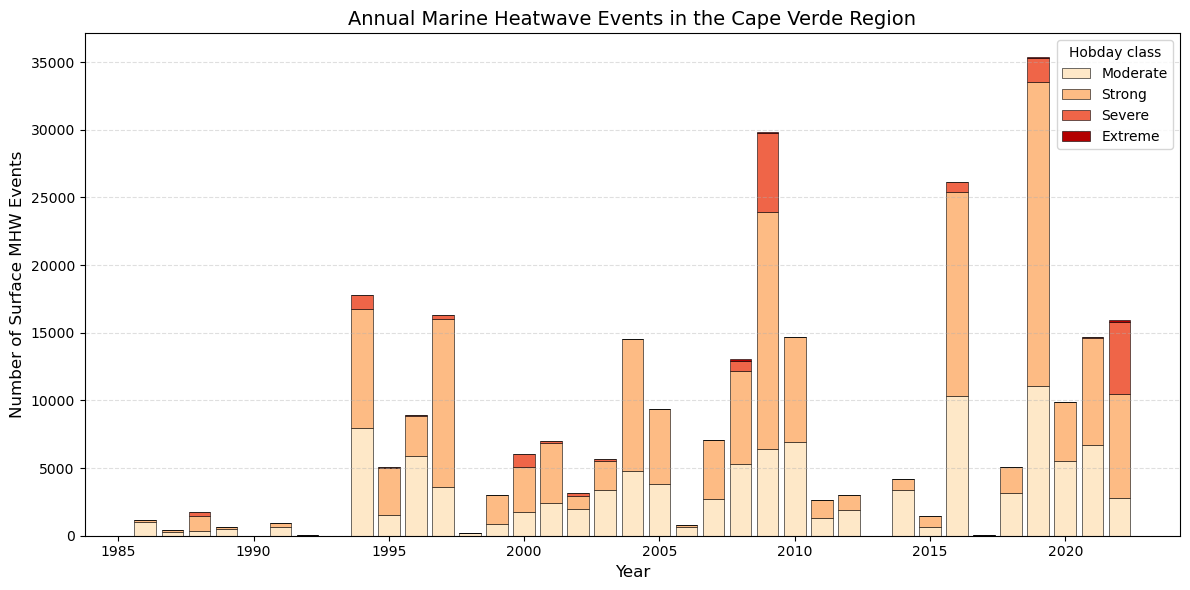

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Colors similar to Hobday category shading
colors = {
    "Moderate": "#fee8c8",
    "Strong":   "#fdbb84",
    "Severe":   "#ef6548",
    "Extreme":  "#b30000"
}

fig, ax = plt.subplots(figsize=(12,6))

years = annual.index.values
bottom = np.zeros(len(years))

for category in cat_order:
    values = annual[category].values
    ax.bar(
        years,
        values,
        bottom=bottom,
        color=colors[category],
        edgecolor='black',
        linewidth=0.4,
        label=category
    )
    bottom += values

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Surface MHW Events", fontsize=12)
ax.set_title("Annual Marine Heatwave Events in the Cape Verde Region", fontsize=14)
ax.legend(title="Hobday class", fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
